# Roles demo

Roles are used to express what a parameter means and how it is rendered. 

In this notebook we create two ops, a Gaussian smooth that returns a gray scale image, and a label_objects that returns an integer indexed label image.
Both are `np.ndarray`, so the type can't differentiate them — the **role** can,
and the renderer can use the role to tweak how they are displayed.

Needs `pip install -e .` in the opspec repo, plus numpy, scikit-image and matplotlib (ipykernel too for VS Code).

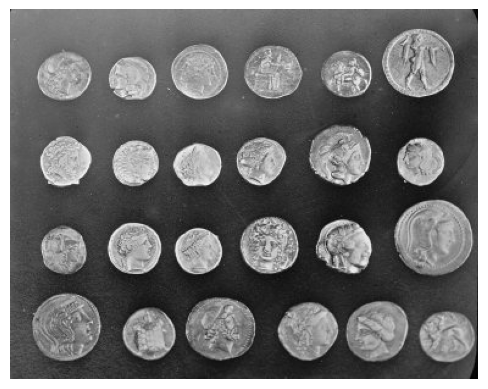

In [6]:
from typing import Annotated

import matplotlib.pyplot as plt
import numpy as np
from skimage import data, filters, measure
from skimage.color import label2rgb

from opspec.op import OpSpec, Role, op

coins = data.coins()
plt.imshow(coins, cmap="gray")
plt.axis("off");

## Declaring the ops

`@op` marks the function. The annotations say what goes in and what comes out:
`Role.image` is a picture, `Role.labels` is a segmentation.

In [7]:
Image = Annotated[np.ndarray, Role.image]
Labels = Annotated[np.ndarray, Role.labels]


@op
def smooth(image: Image, sigma: float = 2.0) -> Image:
    """Blur an image."""
    return filters.gaussian(image, sigma=sigma)


@op
def label_objects(image: Image) -> Labels:
    """Threshold, then number each connected object."""
    return measure.label(image > filters.threshold_otsu(image))

## What opspec read off them

`OpSpec.from_op` turns a signature into plain data. Nothing here knows
what the ops do — only what they declared.

In [3]:
spec = OpSpec.from_op(label_objects)
print(spec.name)
print(spec.params)
print(spec.return_role)

__main__:label_objects
(ParamSpec(name='image', type=<class 'numpy.ndarray'>, default=<class 'inspect._empty'>, role=<Role.image: 'image'>),)
Role.labels


## Drawing by role

One display function for every op. It asks the spec, not the author.

In [4]:
def show(op, result, ax):
    role = OpSpec.from_op(op).return_role
    if role is Role.labels:
        ax.imshow(label2rgb(result, bg_label=0))
    else:
        ax.imshow(result, cmap="gray")
    ax.set_title(f"{op.__name__} -> {role.value}")
    ax.axis("off")

## Running them

An op is an ordinary function, so this process is the host: call it directly.
Later a runner does this in another environment.

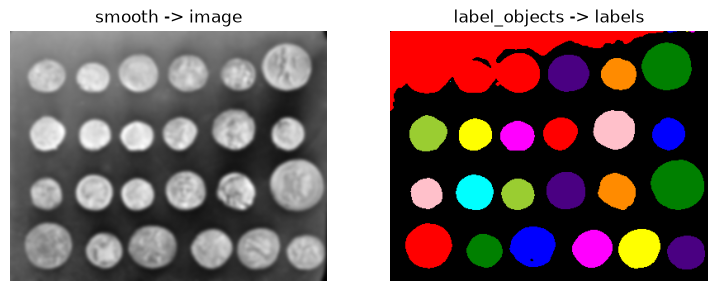

In [5]:
smoothed = smooth(coins, sigma=2.0)
labels = label_objects(smoothed)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
show(smooth, smoothed, axes[0])
show(label_objects, labels, axes[1])

The same two lines drew both results. `smooth` came back grey because it said
`Role.image`; `label_objects` came back in random colours because it said
`Role.labels`. Neither op knows anything about matplotlib.